# 0 Imports

In [10]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from matplotlib import pyplot as plt

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [11]:
fs.jupyter_settings(altura = 8, largura = 16, fonte = 8)
fs.supressao_notacao(casa_decimal = 2)

# 0.2 Load Data

In [12]:
df_hp = fs.load_pickle("../data/interim/5.data_prep.pkl")
df_hp.sample(5)

,customer_id,faturamento,recencia_days,frequencia,avg_faturamento,retornos
2265,14111,-0.16,-1.51,-0.03,0.00,0.11
3562,15568,-0.15,-2.30,-0.18,-0.04,-0.50
3357,12879,-0.18,-0.66,-0.18,-0.01,0.11
1917,16976,-0.22,1.01,-0.55,0.04,-0.50
1468,13717,-0.07,-0.92,0.21,-0.04,0.11


# 1.0 Hyper

In [13]:
X = df_hp.drop(columns=["customer_id"])
X.head()

,faturamento,recencia_days,frequencia,avg_faturamento,retornos
0,0.32,1.33,1.59,-0.03,0.11
1,0.13,-0.45,0.48,-0.03,1.43
2,0.42,-2.30,0.88,-0.03,0.48
3,-0.13,0.03,0.09,-0.02,-0.50
4,-0.14,1.22,-0.18,0.14,0.76


In [14]:
clusters = [2,3,4,5,6,7,8,9,10]
kmeans = KMeans( init='random', n_init=10, max_iter=300, random_state=42)

## 1.1. Within-Cluster Sum of Square (WSS)

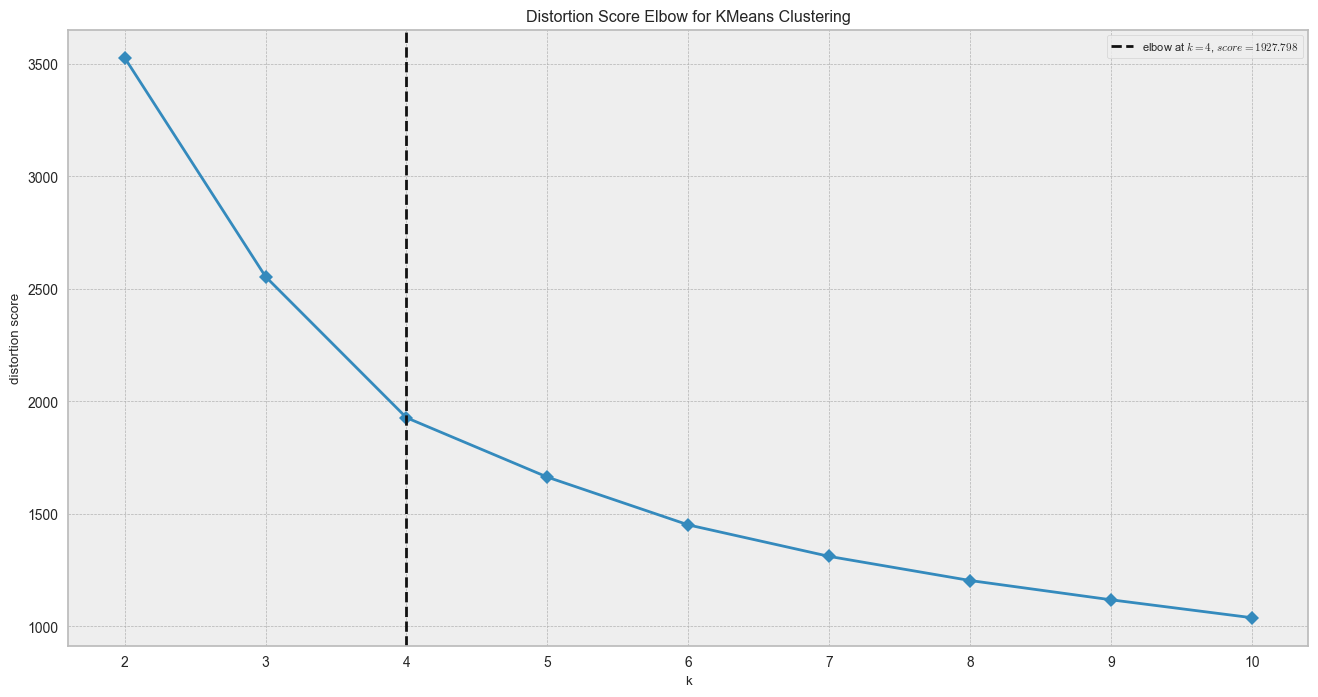

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [15]:
kmeans_wss = KElbowVisualizer(kmeans, k=clusters, timings=False, force_model=True)
kmeans_wss.fit(X)
kmeans_wss.show()

## 1.2. Silhouette Score (SS)

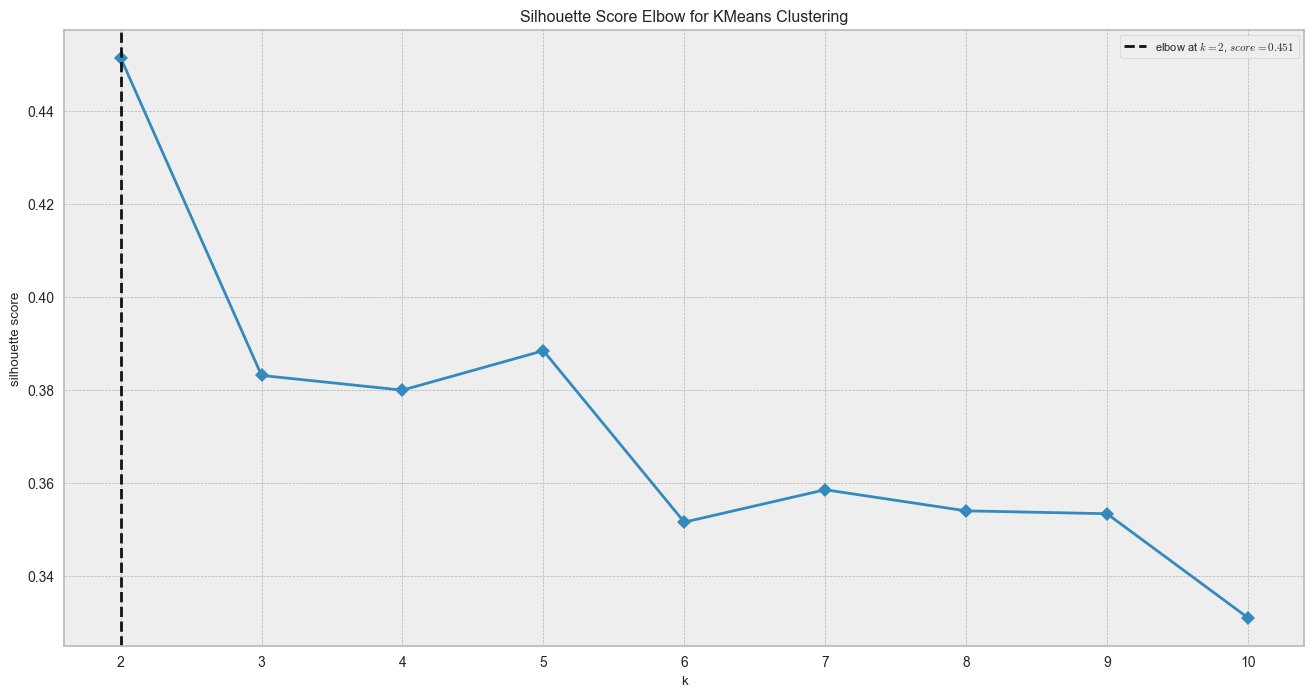

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [16]:
kmeans_ss = KElbowVisualizer( kmeans, k=clusters, metric='silhouette', timings=False, force_model=True)
kmeans_ss.fit(X)
kmeans_ss.show()

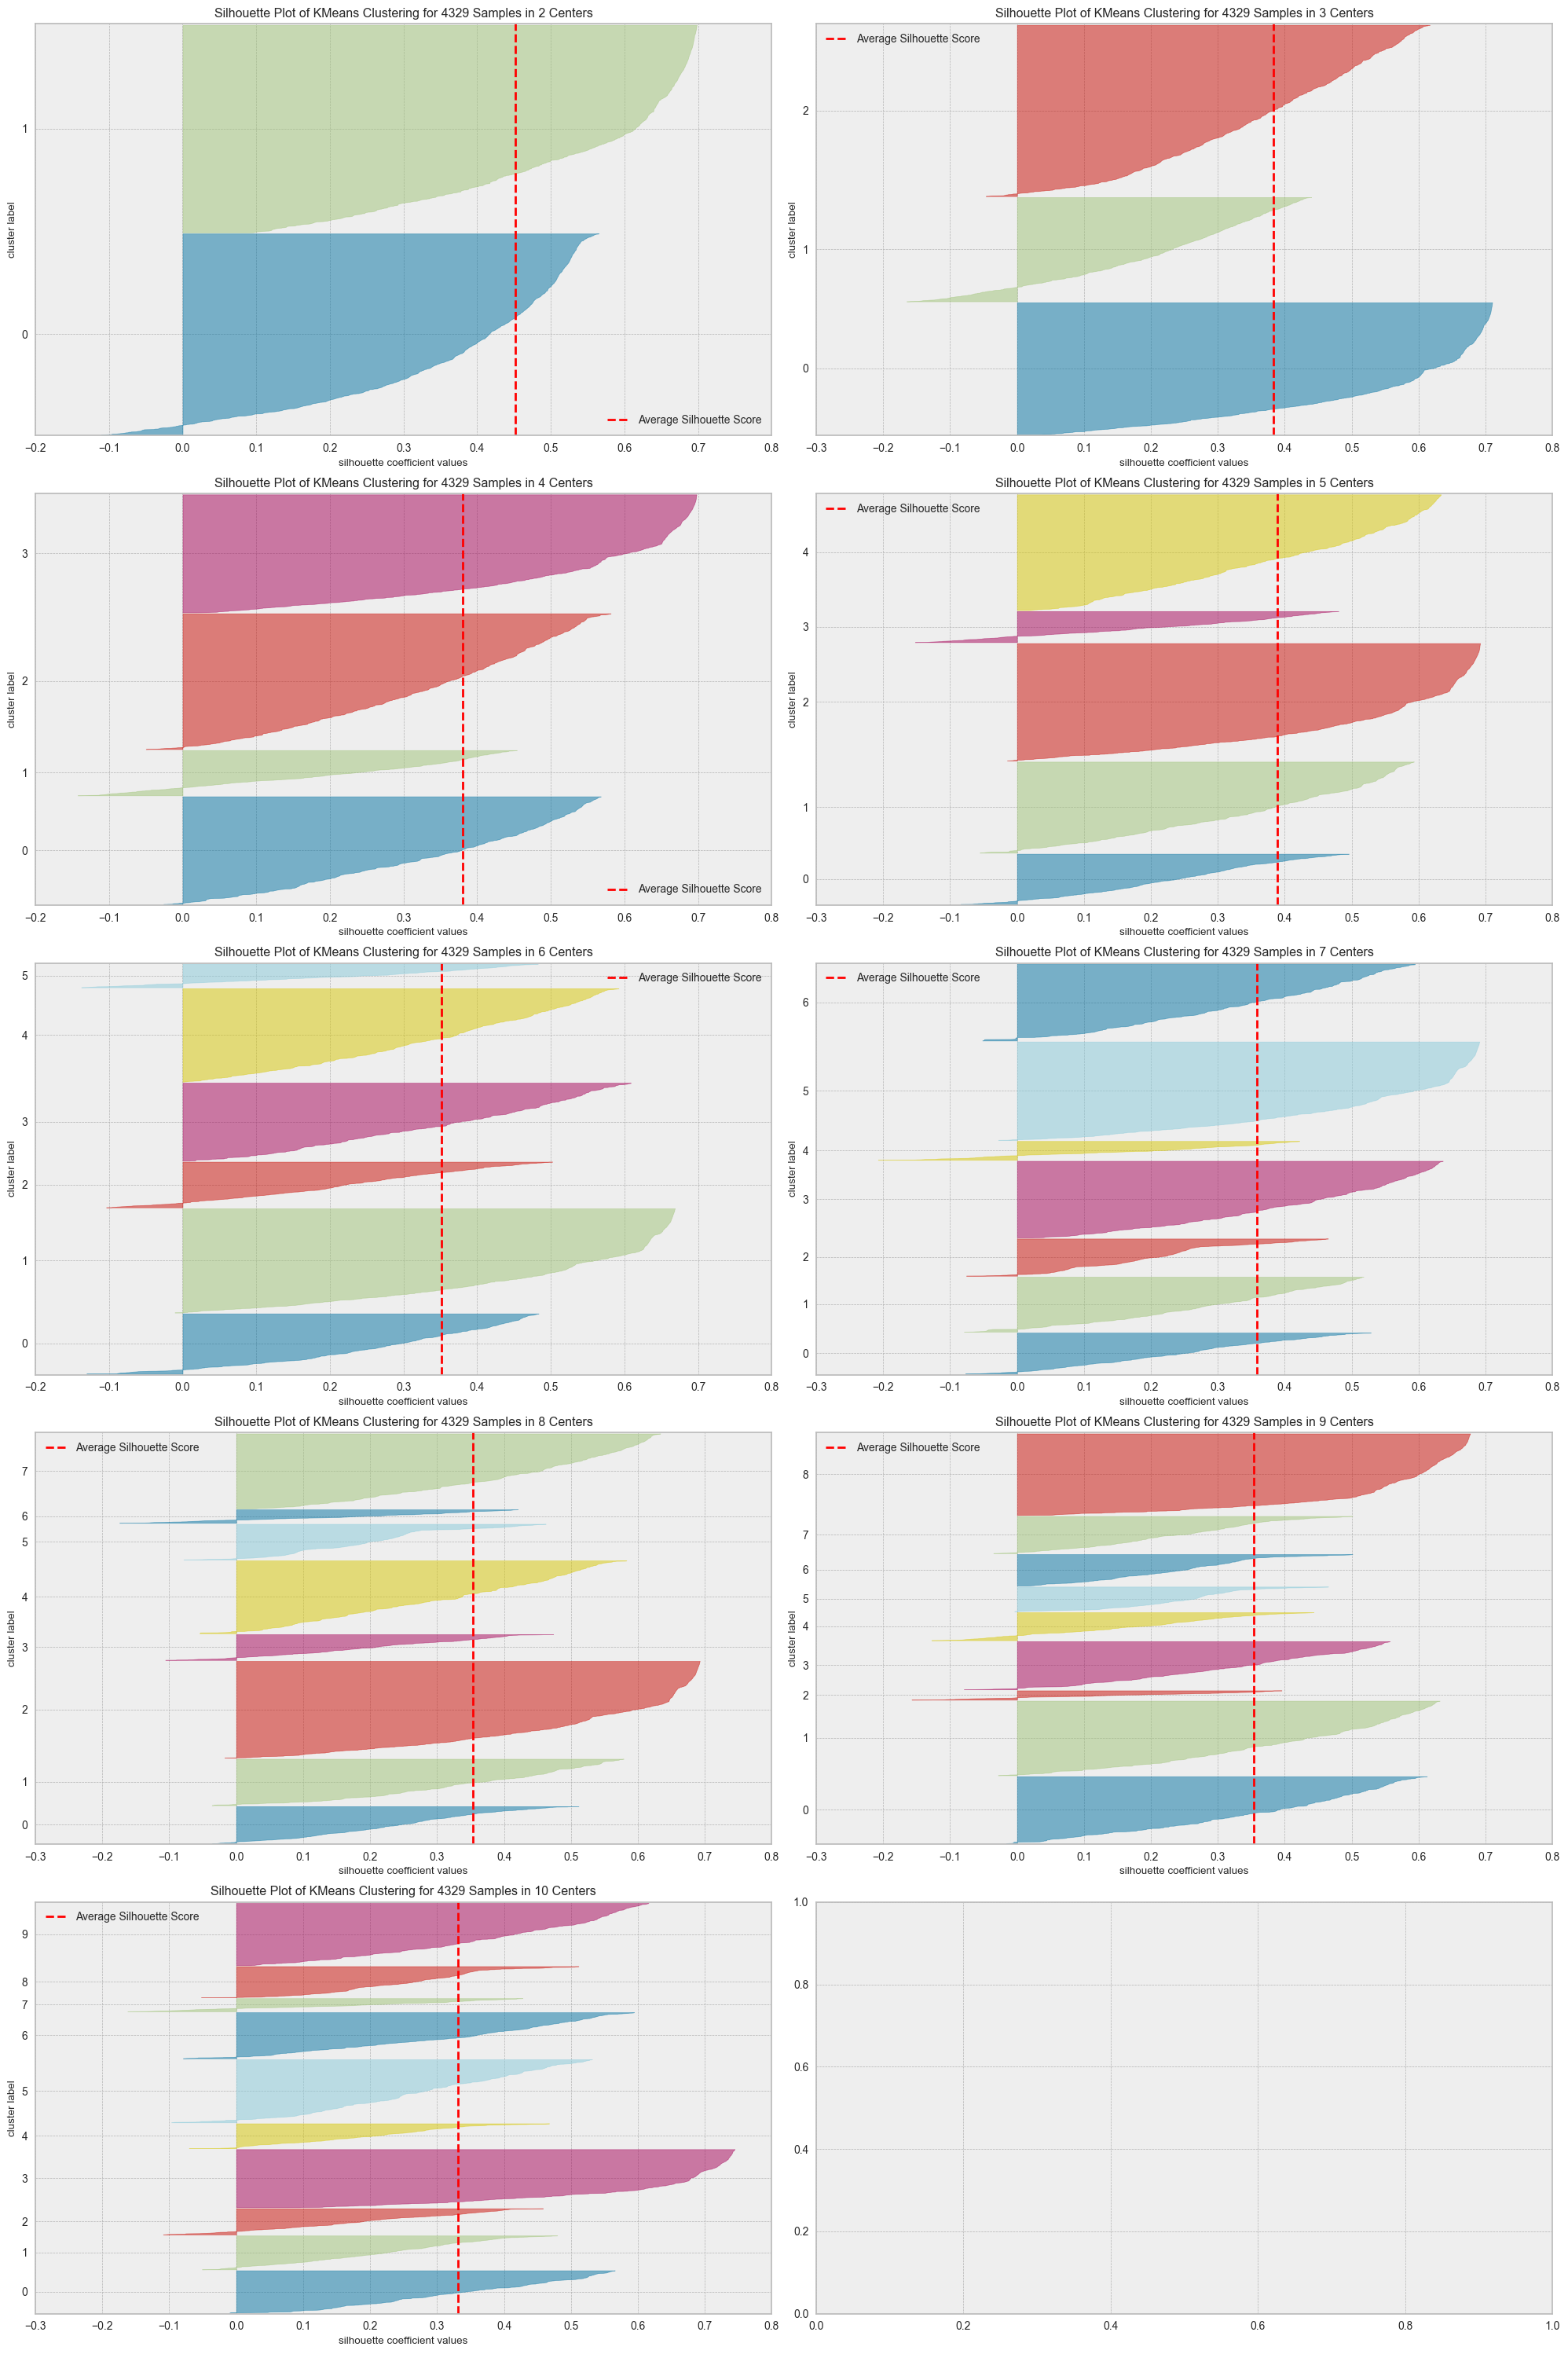

In [17]:
fig, ax = plt.subplots( 5, 2, figsize=(20, 30))

for k in clusters:
    kmeans_viz = KMeans( n_clusters = k, init='random', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(k,2)
    visualiser = SilhouetteVisualizer(kmeans_viz, colors = 'yellowbrick', force_model=True, ax=ax[q-1][mod])
    visualiser.fit(X)
    visualiser.finalize()

plt.tight_layout()
plt.show()

# 2. Definição de K

K=4

# 3 Exportar dados utilizados

In [18]:
fs.save_pickle(X,'../data/interim/7.data-k-definition.pkl')